In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

from src.utils.utils import find_project_root, load_ligand_models 

BASE_DIR = find_project_root()

DATA_DIR = BASE_DIR / "data" / "processed" 

from figures.fig_scripts.fig1_functions import *
from src.preprocessing.raw_data_preprocessing import *
from src.analysis.Ligand4PL import FourPLGeneModel

/home/labs/antebilab/guyilan/.conda/envs/paper_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading Noramlized KS-FDR filtered data frame

In [3]:
df = pd.read_parquet(DATA_DIR / "cpm_df.parquet")

### Supplementary panel A: BMP4 significant genes fractional expression levels across concentrations

In [38]:
models = load_ligand_models(subset=[])

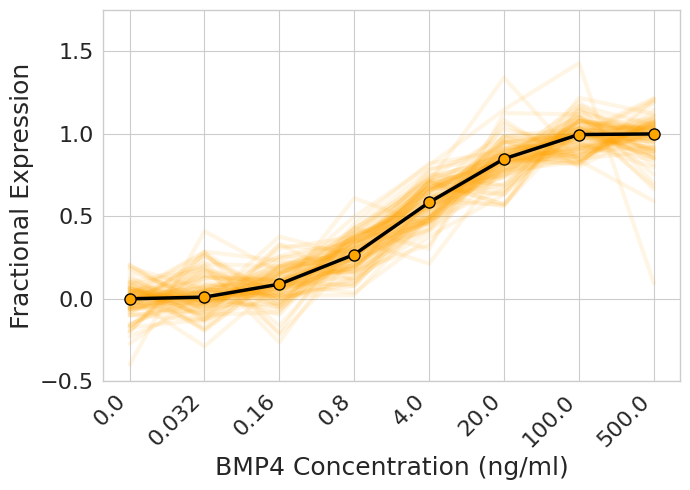

In [ ]:
bmp4_model = models["BMP4"]
plot_fractional_expression(
    "BMP4",
    bmp4_model.norm_exp_all_genes[bmp4_model.ligand_sig_genes_from_dict],
    bmp4_model.concentrations,
    save=False,
    plot_median=True,
    supp=True,
)

### Supplementary panel B: BMP6 significant genes fractional expression levels across concentrations

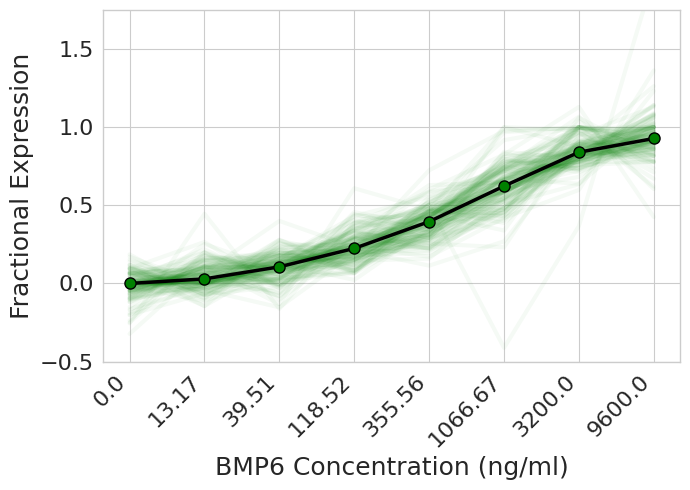

In [ ]:
bmp6_model = models["BMP6"]
plot_fractional_expression(
    "BMP6",
    bmp6_model.norm_exp_all_genes[bmp6_model.ligand_sig_genes_from_dict],
    bmp6_model.concentrations,
    save=False,
    plot_median=True,
    supp=True,
)

### Supplementary panel C: BMP9 significant genes fractional expression levels across concentrations

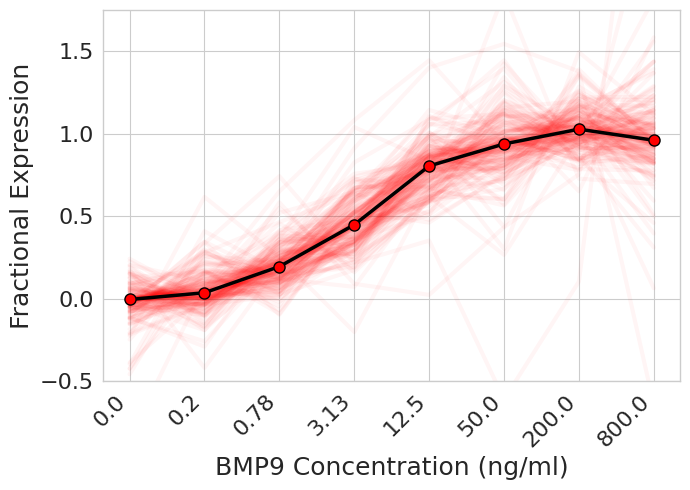

In [ ]:
bmp9_model = models["BMP9"]
plot_fractional_expression(
    "BMP9",
    bmp9_model.norm_exp_all_genes[bmp9_model.ligand_sig_genes_from_dict],
    bmp9_model.concentrations,
    save=False,
    plot_median=True,
    supp=True,
)

### Supplementary panel D: BMP10 significant genes fractional expression levels across concentrations

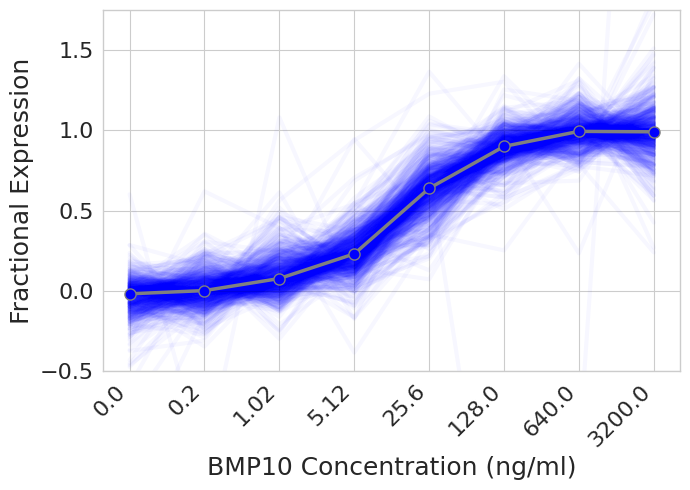

In [ ]:
bmp10_model = models["BMP10"]
plot_fractional_expression(
    "BMP10",
    bmp10_model.norm_exp_all_genes[bmp10_model.ligand_sig_genes_from_dict],
    bmp10_model.concentrations,
    save=False,
    plot_median=True,
    supp=True,
)

### Supplementary panel E: TGFb1 significant genes fractional expression levels across concentrations

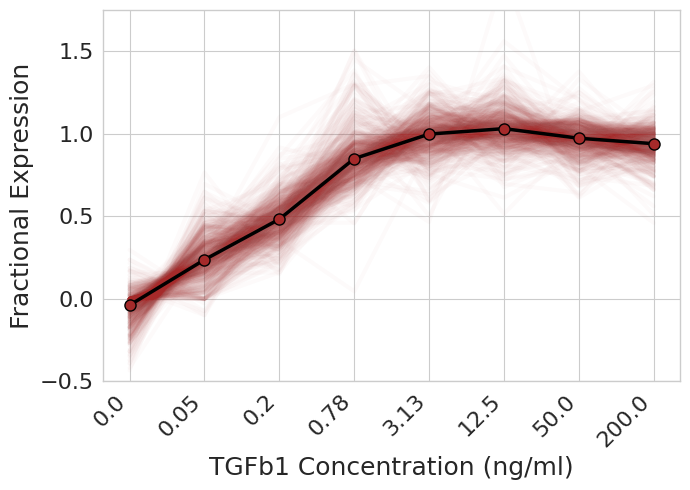

In [ ]:
tgfb_model = models["TGFb1"]
plot_fractional_expression(
    "TGFb1",
    tgfb_model.norm_exp_all_genes[tgfb_model.ligand_sig_genes_from_dict],
    tgfb_model.concentrations,
    save=False,
    plot_median=True,
    supp=True,
)

### Supplementary panel F: GDF5 significant genes fractional expression levels across concentrations

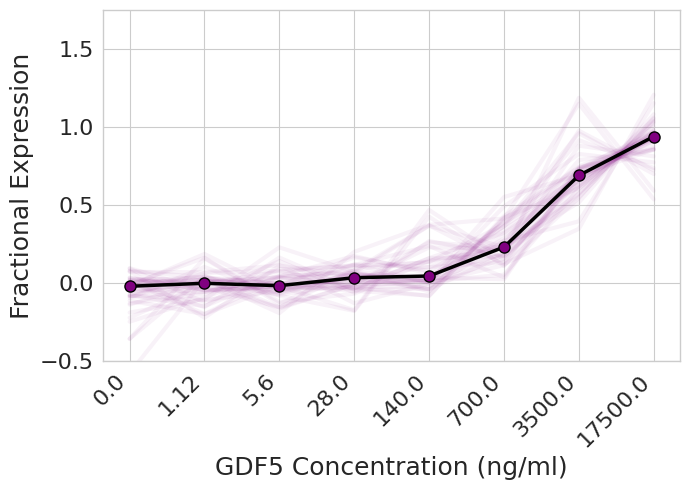

In [ ]:
gdf5_model = models["GDF5"]
plot_fractional_expression(
    "GDF5",
    gdf5_model.norm_exp_all_genes[gdf5_model.ligand_sig_genes_from_dict],
    gdf5_model.concentrations,
    save=False,
    plot_median=True,
    supp=True,
)

### Supplementary panel G: ligands 6HR vs 3HR UMAP

In [47]:
raw_data, meta_data, features, barcodes = load_files(exp1=True)

#### Validate and prepare single cell data

In [48]:
counts, gene_names, cell_barcodes, features, meta_data = validate_and_prepare_data(
    raw_data, meta_data, features
)

Matrix shape (cells × genes): (15059, 27999)


#### Quality control filtering steps

In [49]:
counts, meta_data, qc_mask, n_genes_per_cell, mito_pct_per_cell = apply_qc_filtering(
    counts, features, meta_data, threshold=2800
)


Step 1 — QC cell filtering (genes > 2800 & mito% < 10%)
  Removed : 2862 cells
  Retained: 12197 cells
  Matrix after cell filtering: (12197, 27999)


In [50]:
counts, meta_data, features = remove_unknown_cells(counts, meta_data, features)


Step 2 — Remove unknown cells
  Removed : 1214 cells
  Retained: 10983 cells
  Matrix after removing unknowns: (10983, 27999)


#### Gene filtering:

In [51]:
counts, features, meta_data, gene_names = filter_genes(counts, features, meta_data)



Step 3 — Gene filtering (remove zero-count genes)
  Removed : 9334 genes
  Retained: 18665 genes
  Matrix after gene filtering: (10983, 18665)


In [52]:
counts, features, gene_names = merge_duplicate_genes(counts, features, gene_names)


Step 4 — Merge duplicate gene symbols
  Genes before: 18665
  Duplicate gene names collapsed: 12
  Genes after : 18653
  Matrix after merging: (10983, 18653)


In [53]:
cell_barcodes = meta_data["cell_barcode"].values
cpm_counts = apply_cpm_normalization(counts, gene_names, cell_barcodes)


Step 5 — CPM normalisation
  Library size — min: 7794.0, median: 34336, max: 145492.0
  ✓ normalized_df shape: (10983, 18653)


In [54]:
#make cpm data frame:
cpm_df = pd.DataFrame(
    cpm_counts.toarray().astype(np.float32),
    index=meta_data["sample_id"],
    columns=gene_names
)
cpm_df.index.name = None

h2b_vec = cpm_df.pop("H2BCITRINE")

In [55]:
cpm_df.to_parquet(Path(DATA_DIR) / "cpm_df_exp1.parquet", compression='snappy')
h2b_vec.to_frame().to_parquet(Path(DATA_DIR) / "cpm_h2b_vec_exp1.parquet", compression='snappy')

In [7]:
df_exp1 = pd.read_parquet(DATA_DIR / "cpm_df_exp1.parquet")

models = load_ligand_models(subset=["BMP4"])
bmp4_model = models["BMP4"]

/home/labs/antebilab/guyilan/.conda/envs/paper_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


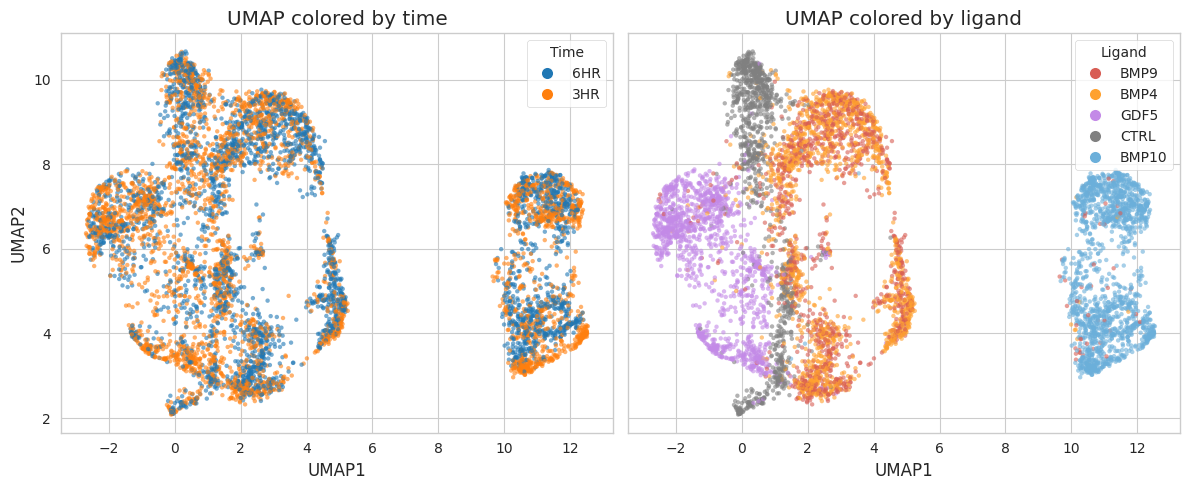

In [25]:
sig_genes_list = bmp4_model.all_genes_list
out = run_umap_panel_from_df_exp1(df_exp1, sig_genes_list, save=True)

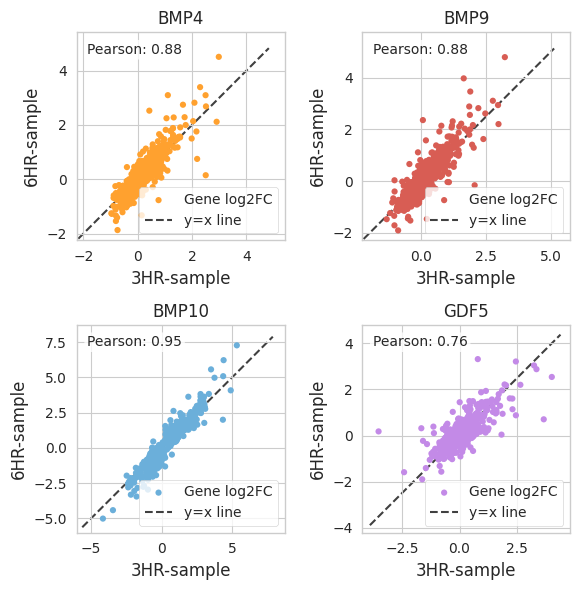

In [24]:
df_exp1_singles = out["df_exp1_filt"]
emb_df = out["emb_df"]
# ligand_palette = get_umap_ligand_palette(emb_df)

df_filt = build_timepoint_fc_table(df_exp1_singles)

plot_3hr_6hr_regression_grid(
    df_filt=df_filt,
    ligands=["BMP4", "BMP9", "BMP10", "GDF5"],
    # ligand_palette=ligand_palette,
    save=True,
)